In [369]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import OneHotEncoder

### Importar el dataset

In [370]:
data = pd.read_csv('./Data.csv')

C:\Users\Dell\AppData\Local\Temp\ipykernel_24036\2202040361.py:1: DtypeWarning: Columns (30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('./Data.csv')


### Informacion de la data

In [371]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17087 entries, 0 to 17086
Data columns (total 77 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   md5                         17087 non-null  object 
 1   sha1                        17087 non-null  object 
 2   file_extension              17087 non-null  object 
 3   EntryPoint                  17087 non-null  object 
 4   PEType                      17087 non-null  object 
 5   MachineType                 17087 non-null  object 
 6   magic_number                17087 non-null  object 
 7   bytes_on_last_page          17087 non-null  object 
 8   pages_in_file               17087 non-null  object 
 9   relocations                 17087 non-null  object 
 10  size_of_header              17087 non-null  object 
 11  min_extra_paragraphs        17087 non-null  object 
 12  max_extra_paragraphs        17087 non-null  object 
 13  init_ss_value               170

### Numero de columnas y filas

In [372]:
print("Shape", data.shape)
print("Filas", data.shape[0])
print("Columnas", data.shape[1])

Shape (17087, 77)
Filas 17087
Columnas 77


### Listar todas las columnas por tipo de varibale: categorica y numerica

In [373]:
# --- Detectar columnas categóricas ---
cat_cols = data.select_dtypes(include=["object"]).columns.tolist()

print("Columnas categóricas:")
print(cat_cols)

Columnas categóricas:
['md5', 'sha1', 'file_extension', 'EntryPoint', 'PEType', 'MachineType', 'magic_number', 'bytes_on_last_page', 'pages_in_file', 'relocations', 'size_of_header', 'min_extra_paragraphs', 'max_extra_paragraphs', 'init_ss_value', 'init_sp_value', 'init_ip_value', 'init_cs_value', 'over_lay_number', 'oem_identifier', 'address_of_ne_header', 'Magic', 'SizeOfCode', 'SizeOfInitializedData', 'SizeOfUninitializedData', 'AddressOfEntryPoint', 'BaseOfCode', 'BaseOfData', 'ImageBase', 'SectionAlignment', 'FileAlignment', 'OperatingSystemVersion', 'ImageVersion', 'SizeOfImage', 'SizeOfHeaders', 'Checksum', 'Subsystem', 'DllCharacteristics', 'SizeofStackReserve', 'SizeofStackCommit', 'SizeofHeapCommit', 'SizeofHeapReserve', 'LoaderFlags', 'text_VirtualSize', 'text_VirtualAddress', 'text_SizeOfRawData', 'text_PointerToRawData', 'text_PointerToRelocations', 'text_PointerToLineNumbers', 'text_Characteristics', 'rdata_VirtualSize', 'rdata_VirtualAddress', 'rdata_SizeOfRawData', 'rda

In [374]:
# --- Detectar columnas numericas ---
num_cols = data.select_dtypes(include=["float64"]).columns.tolist()

print("Columnas numericas detectadas:")
print(num_cols )

Columnas numericas detectadas:
['registry_read', 'registry_write', 'registry_delete', 'registry_total', 'network_threats', 'network_dns', 'network_http', 'network_connections', 'processes_malicious', 'processes_suspicious', 'processes_monitored', 'total_procsses', 'files_malicious', 'files_suspicious', 'files_text', 'files_unknown', 'dlls_calls', 'apis']


### Cantidad de  variables numericas y categoricas

In [375]:
data.dtypes.value_counts()


object     59
float64    18
Name: count, dtype: int64

### Revisar la cardinalidad de las variables categoricas
Para ver si se aplica one-hot Encoder o Label Enconder
One-hot Se aplica a variables que tenga pocas categorias
Label Encoder 
Ventajas no crea varias columnas Útil para modelos que no interpretan los números como un orden (ej. árboles: Decision Tree, Random Forest, XGBoost, LightGBM). 
Todas esas variables estan categorizadas como object, en las cuales algunas eran object y otras eran hexcd que estans como object


In [376]:
# --- Revisar cardinalidad (número de valores únicos) ---
cat_cardinalidad = {c: data[c].nunique() for c in cat_cols}
print("\nCardinalidad de columnas categóricas:")
for col, nunique in cat_cardinalidad.items():
    print(f"{col}: {nunique}")


Cardinalidad de columnas categóricas:
md5: 9855
sha1: 9856
file_extension: 1
EntryPoint: 6191
PEType: 3
MachineType: 3
magic_number: 2
bytes_on_last_page: 64
pages_in_file: 63
relocations: 43
size_of_header: 43
min_extra_paragraphs: 42
max_extra_paragraphs: 40
init_ss_value: 40
init_sp_value: 46
init_ip_value: 52
init_cs_value: 52
over_lay_number: 49
oem_identifier: 47
address_of_ne_header: 69
Magic: 3
SizeOfCode: 2488
SizeOfInitializedData: 2204
SizeOfUninitializedData: 404
AddressOfEntryPoint: 5908
BaseOfCode: 336
BaseOfData: 942
ImageBase: 99
SectionAlignment: 9
FileAlignment: 8
OperatingSystemVersion: 27
ImageVersion: 116
SizeOfImage: 1997
SizeOfHeaders: 24
Checksum: 3621
Subsystem: 5
DllCharacteristics: 57
SizeofStackReserve: 57
SizeofStackCommit: 42
SizeofHeapCommit: 10
SizeofHeapReserve: 22
LoaderFlags: 4
text_VirtualSize: 5553
text_VirtualAddress: 121
text_SizeOfRawData: 2143
text_PointerToRawData: 124
text_PointerToRelocations: 6
text_PointerToLineNumbers: 12
text_Characteris

### Ver los valores nulos

In [377]:
print("\n Conteo de valores nulos por columna:")
print(data.isnull().sum())


 Conteo de valores nulos por columna:
md5               0
sha1              0
file_extension    0
EntryPoint        0
PEType            0
                 ..
dlls_calls        0
apis              0
Class             0
Category          0
Family            0
Length: 77, dtype: int64


### Valores vacios por columna

In [378]:
# 4) Detectar valores vacíos (celdas con string vacío o solo espacios)
print("\n Conteo de valores vacíos por columna:")
print((data.applymap(lambda x: str(x).strip() == '')).sum())




 Conteo de valores vacíos por columna:


C:\Users\Dell\AppData\Local\Temp\ipykernel_24036\2919232096.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print((data.applymap(lambda x: str(x).strip() == '')).sum())


md5               0
sha1              0
file_extension    0
EntryPoint        0
PEType            0
                 ..
dlls_calls        0
apis              0
Class             0
Category          0
Family            0
Length: 77, dtype: int64


### Ver  filas vacias

In [379]:
# 5) Detectar filas completamente vacías
print("\n Número de filas completamente vacías:")
print(data.isnull().all(axis=1).sum())


 Número de filas completamente vacías:
0


In [380]:
# 6) Ver filas sospechosas (con valores nulos o vacíos en alguna columna)
print("\n Filas con valores nulos o vacíos:")
print(data[data.isnull().any(axis=1) | data.applymap(lambda x: str(x).strip() == '').any(axis=1)])


 Filas con valores nulos o vacíos:
Empty DataFrame
Columns: [md5, sha1, file_extension, EntryPoint, PEType, MachineType, magic_number, bytes_on_last_page, pages_in_file, relocations, size_of_header, min_extra_paragraphs, max_extra_paragraphs, init_ss_value, init_sp_value, init_ip_value, init_cs_value, over_lay_number, oem_identifier, address_of_ne_header, Magic, SizeOfCode, SizeOfInitializedData, SizeOfUninitializedData, AddressOfEntryPoint, BaseOfCode, BaseOfData, ImageBase, SectionAlignment, FileAlignment, OperatingSystemVersion, ImageVersion, SizeOfImage, SizeOfHeaders, Checksum, Subsystem, DllCharacteristics, SizeofStackReserve, SizeofStackCommit, SizeofHeapCommit, SizeofHeapReserve, LoaderFlags, text_VirtualSize, text_VirtualAddress, text_SizeOfRawData, text_PointerToRawData, text_PointerToRelocations, text_PointerToLineNumbers, text_Characteristics, rdata_VirtualSize, rdata_VirtualAddress, rdata_SizeOfRawData, rdata_PointerToRawData, rdata_PointerToRelocations, rdata_PointerToLi

C:\Users\Dell\AppData\Local\Temp\ipykernel_24036\3230463956.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(data[data.isnull().any(axis=1) | data.applymap(lambda x: str(x).strip() == '').any(axis=1)])


### Distribucion multiclase Bening, Ransoware y Trojan
Esta desbalanceada la clase

Distribución de clases:
 Category
Benign        10876
Ransomware     4762
Trojan         1449
Name: count, dtype: int64


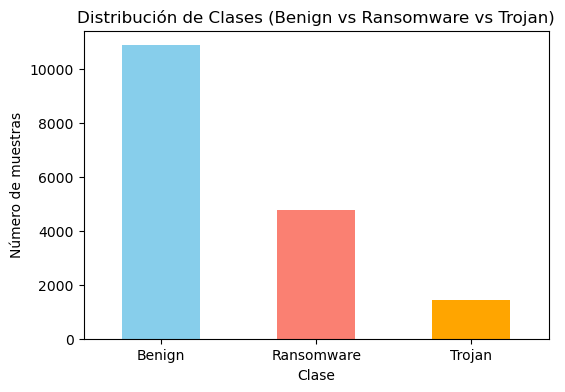

In [381]:
# Contar muestras por categoría
class_counts = data["Category"].value_counts()

# Imprimir valores exactos
print("Distribución de clases:\n", class_counts)

# Graficar
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
class_counts.plot(kind="bar", color=["skyblue", "salmon", "orange"])
plt.title("Distribución de Clases (Benign vs Ransomware vs Trojan)")
plt.xlabel("Clase")
plt.ylabel("Número de muestras")
plt.xticks(rotation=0)
plt.show()


### Definir features (X)
Ahora X contiene solo las características.

In [382]:
X = data.drop(columns=["Class", "Category", "Family"], errors="ignore")
print("Shape de X (features):", X.shape)

Shape de X (features): (17087, 74)


### Definir target

In [383]:
y = data["Category"] # multiclase: Benign, Ransomware, Trojan
print("Shape de y (target):", y.shape)

Shape de y (target): (17087,)


### Eliminacion de columnas que no aportan valor

In [384]:
# 3. Eliminar columnas que no aportan valor
# md5, sha1 identificador
# file_extension tipo de extension exe 
#  "text_PointerToRelocations", "text_PointerToLineNumbers", solo tiene 0
#   "rdata_PointerToRelocations", "rdata_PointerToLineNumbers", solo tiene 0
#magic number no aporta 
# No aporta magic debido a que solo tiene una categoria
cols_drop = [
    "md5", "sha1","file_extension","magic_number","oem_identifier", "address_of_ne_header",
     "text_PointerToRelocations", "text_PointerToLineNumbers",
    "rdata_PointerToRelocations", "rdata_PointerToLineNumbers",
    "Class", "Category", "Family", "registry_total", "total_procsses", "network_threats", "Magic", "OperatingSystemVersion", "ImageVersion"
]
X = X.drop(columns=cols_drop, errors="ignore")
print("Shape de X después de eliminar columnas no útiles:", X.shape)


Shape de X después de eliminar columnas no útiles: (17087, 58)


In [385]:
print("Shape del dataset limpio:", X.shape)
print("Columnas:", X.columns.tolist())


Shape del dataset limpio: (17087, 58)
Columnas: ['EntryPoint', 'PEType', 'MachineType', 'bytes_on_last_page', 'pages_in_file', 'relocations', 'size_of_header', 'min_extra_paragraphs', 'max_extra_paragraphs', 'init_ss_value', 'init_sp_value', 'init_ip_value', 'init_cs_value', 'over_lay_number', 'SizeOfCode', 'SizeOfInitializedData', 'SizeOfUninitializedData', 'AddressOfEntryPoint', 'BaseOfCode', 'BaseOfData', 'ImageBase', 'SectionAlignment', 'FileAlignment', 'SizeOfImage', 'SizeOfHeaders', 'Checksum', 'Subsystem', 'DllCharacteristics', 'SizeofStackReserve', 'SizeofStackCommit', 'SizeofHeapCommit', 'SizeofHeapReserve', 'LoaderFlags', 'text_VirtualSize', 'text_VirtualAddress', 'text_SizeOfRawData', 'text_PointerToRawData', 'text_Characteristics', 'rdata_VirtualSize', 'rdata_VirtualAddress', 'rdata_SizeOfRawData', 'rdata_PointerToRawData', 'rdata_Characteristics', 'registry_read', 'registry_write', 'registry_delete', 'network_dns', 'network_http', 'network_connections', 'processes_maliciou

### Renombrar variables 

In [386]:
# Mapeo de nombres largos a cortos
rename_map = {
    "Intel 386 or later, and compatibles": "x86",
    "AMD AMD64": "x64",
    "MachineType": "Unknown"  # por si aparece un valor raro como 'MachineType'
}

# Aplicar reemplazo en la columna MachineType
if "MachineType" in X.columns:
    X["MachineType"] = X["MachineType"].replace(rename_map)

print("Valores únicos después del renombrado:")
print(X["MachineType"].unique())



Valores únicos después del renombrado:
['x64' 'x86' 'Unknown (0)']


In [387]:
# Reemplazar '0' por IMAGE_SUBSYSTEM_UNKNOWN
if "Subsystem" in X.columns:
    X["Subsystem"] = X["Subsystem"].replace("0", "IMAGE_SUBSYSTEM_UNKNOWN")

print("Categorías únicas después:", X["Subsystem"].unique())
print("Conteo actualizado:")
print(X["Subsystem"].value_counts())




Categorías únicas después: ['IMAGE_SUBSYSTEM_WINDOWS_GUI' 'IMAGE_SUBSYSTEM_WINDOWS_CUI'
 'IMAGE_SUBSYSTEM_NATIVE' 'IMAGE_SUBSYSTEM_UNKNOWN']
Conteo actualizado:
Subsystem
IMAGE_SUBSYSTEM_WINDOWS_GUI    13169
IMAGE_SUBSYSTEM_WINDOWS_CUI     3487
IMAGE_SUBSYSTEM_UNKNOWN          341
IMAGE_SUBSYSTEM_NATIVE            90
Name: count, dtype: int64


### Verificar las variables con error

In [388]:
# Ver todas las filas que tienen ese valor
X[X["PEType"] == "Unknown (0x2000)"]


,EntryPoint,PEType,MachineType,bytes_on_last_page,pages_in_file,relocations,size_of_header,min_extra_paragraphs,max_extra_paragraphs,init_ss_value,...,network_connections,processes_malicious,processes_suspicious,processes_monitored,files_malicious,files_suspicious,files_text,files_unknown,dlls_calls,apis
999,0x0000,Unknown (0x2000),x86,0x0050,0x0002,0x0000,0x0004,0x000F,0xFFFF,0x0000,...,4.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0
9655,0x2800a,Unknown (0x2000),x86,0x0050,0x0002,0x0000,0x0004,0x0000,0xFFFF,0x0000,...,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,338.0


### Eliminar filas que tienen errores

In [389]:
# Eliminar filas con PEType = 'Unknown (0x2000)'
if "PEType" in X.columns:
    filas_iniciales = X.shape[0]
    X = X[X["PEType"] != "Unknown (0x2000)"]
    print(f"Filas eliminadas: {filas_iniciales - X.shape[0]}")



Filas eliminadas: 2


In [390]:
# Eliminar filas con MachineType = 'Unknown 
# Número de filas antes
filas_iniciales = X.shape[0]

# Eliminar filas donde MachineType == "Unknown (0)"
if "MachineType" in X.columns:
    X = X[X["MachineType"] != "Unknown (0)"]

# Número de filas después
filas_finales = X.shape[0]

print(f"Filas eliminadas: {filas_iniciales - filas_finales}")
print(f"Shape actual de X: {X.shape}")
print("Valores únicos en MachineType:", X["MachineType"].unique())



Filas eliminadas: 6
Shape actual de X: (17079, 58)
Valores únicos en MachineType: ['x64' 'x86']


### Limpieza de la variable AddressOfEntryPoint

In [391]:
# === Función para limpiar hex con texto extra ===
def limpiar_hex_con_texto(val):
    if isinstance(val, str):
        # Buscar un valor hexadecimal en el string
        match = re.search(r"0x[0-9A-Fa-f]+", val)
        if match:
            try:
                return float(int(match.group(0), 16))  # convertir a float64
            except:
                return np.nan
        return np.nan
    return val

# === Aplicar solo si existe la columna ===
if "AddressOfEntryPoint" in X.columns:
    X["AddressOfEntryPoint"] = X["AddressOfEntryPoint"].map(limpiar_hex_con_texto).astype("float64")
    print("Columna AddressOfEntryPoint convertida a float64.")



Columna AddressOfEntryPoint convertida a float64.


### Convertir las variables  hexadecimales a float

In [392]:
import re
import numpy as np

# === 1) Define las categóricas que NO deben tocarse ===
CATEGORICAS_EXCLUIR = [
    "MachineType", "Subsystem", "PEType",
    "DllCharacteristics", "text_Characteristics", "rdata_Characteristics"
]
cat_presentes = [c for c in CATEGORICAS_EXCLUIR if c in X.columns]

# === 2) Funciones auxiliares ===
HEX_REGEX = re.compile(r"^\s*0[xX][0-9A-Fa-f]+\s*$")

def es_hex(s: str) -> bool:
    return isinstance(s, str) and bool(HEX_REGEX.match(s.strip()))

def parsear_num(val):
    """Convierte hex ('0x...') o decimal en texto a float64. Si falla -> NaN."""
    if isinstance(val, str):
        s = val.strip()
        if es_hex(s):
            try:
                return float(int(s, 16))
            except:
                return np.nan
        try:
            return float(s)
        except:
            return np.nan
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return np.nan
    try:
        return float(val)
    except:
        return np.nan

# === 3) Detectar columnas 'object' con al menos un valor hexadecimal ===
hex_cols = []
for col in X.select_dtypes(include=["object"]).columns:
    if col in cat_presentes:
        continue  # excluye categóricas
    muestra = X[col].dropna().astype(str)
    if muestra.head(200).map(es_hex).any():
        hex_cols.append(col)

print("Columnas detectadas con valores hexadecimales:", hex_cols)

# === 4) Convertir SOLO esas columnas a float64 ===
for col in hex_cols:
    X[col] = X[col].map(parsear_num).astype("float64")

# (Opcional) Verificación
print(X[hex_cols].dtypes if hex_cols else "No se detectaron columnas hexadecimales.")

# === 5) Exportar a CSV ===
output_path = "dataset_valoresfloat.csv"
X.to_csv(output_path, index=False, encoding="utf-8")
print(f"Archivo exportado a: {output_path}")


Columnas detectadas con valores hexadecimales: ['EntryPoint', 'bytes_on_last_page', 'pages_in_file', 'relocations', 'size_of_header', 'min_extra_paragraphs', 'max_extra_paragraphs', 'init_ss_value', 'init_sp_value', 'init_ip_value', 'init_cs_value', 'over_lay_number', 'SizeOfCode', 'SizeOfInitializedData', 'SizeOfUninitializedData', 'BaseOfCode', 'BaseOfData', 'ImageBase', 'SectionAlignment', 'FileAlignment', 'SizeOfImage', 'SizeOfHeaders', 'Checksum', 'SizeofStackReserve', 'SizeofStackCommit', 'SizeofHeapCommit', 'SizeofHeapReserve', 'LoaderFlags', 'text_VirtualSize', 'text_VirtualAddress', 'text_SizeOfRawData', 'text_PointerToRawData', 'rdata_VirtualSize', 'rdata_VirtualAddress', 'rdata_SizeOfRawData', 'rdata_PointerToRawData']
EntryPoint                 float64
bytes_on_last_page         float64
pages_in_file              float64
relocations                float64
size_of_header             float64
min_extra_paragraphs       float64
max_extra_paragraphs       float64
init_ss_value  

In [393]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17079 entries, 0 to 17086
Data columns (total 58 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EntryPoint               17079 non-null  float64
 1   PEType                   17079 non-null  object 
 2   MachineType              17079 non-null  object 
 3   bytes_on_last_page       17079 non-null  float64
 4   pages_in_file            17079 non-null  float64
 5   relocations              17079 non-null  float64
 6   size_of_header           17079 non-null  float64
 7   min_extra_paragraphs     17079 non-null  float64
 8   max_extra_paragraphs     17079 non-null  float64
 9   init_ss_value            17079 non-null  float64
 10  init_sp_value            17079 non-null  float64
 11  init_ip_value            17079 non-null  float64
 12  init_cs_value            17079 non-null  float64
 13  over_lay_number          17079 non-null  float64
 14  SizeOfCode               17

### Convertir las variables categoricas
Hay 6 variables categoricas
One-Hot Encoding a MachineType, Subsystem, PEType.

Multi-Label Binarization a DllCharacteristics, text_Characteristics, rdata_Characteristics.

In [394]:
import ast

# === Variables categóricas ===
categorical_single = ["MachineType", "Subsystem", "PEType"]  # One-Hot Encoding
categorical_multi  = ["DllCharacteristics", "text_Characteristics", "rdata_Characteristics"]  # Multi-Label Binarization

# === 1. Categorías simples (One-Hot) ===
for col in categorical_single:
    if col in X.columns:
        print(f"\n▶ {col} (categorías únicas):")
        print(X[col].unique())

# === 2. Categorías multilabel ===
for col in categorical_multi:
    if col in X.columns:
        print(f"\n▶ {col} (categorías posibles):")
        categorias = set()
        for row in X[col].dropna():
            if isinstance(row, str):
                try:
                    # Convierte el string de lista a lista real
                    items = ast.literal_eval(row)
                    categorias.update(items)
                except:
                    pass
        print(sorted(categorias))
        print(f"Total categorías en {col}: {len(categorias)}")



▶ MachineType (categorías únicas):
['x64' 'x86']

▶ Subsystem (categorías únicas):
['IMAGE_SUBSYSTEM_WINDOWS_GUI' 'IMAGE_SUBSYSTEM_WINDOWS_CUI'
 'IMAGE_SUBSYSTEM_NATIVE' 'IMAGE_SUBSYSTEM_UNKNOWN']

▶ PEType (categorías únicas):
['PE32+' 'PE32']

▶ DllCharacteristics (categorías posibles):
['IMAGE_DLLCHARACTERISTICS_APPCONTAINER', 'IMAGE_DLLCHARACTERISTICS_DYNAMIC_BASE', 'IMAGE_DLLCHARACTERISTICS_FORCE_INTEGRITY', 'IMAGE_DLLCHARACTERISTICS_GUARD_CF', 'IMAGE_DLLCHARACTERISTICS_HIGH_ENTROPY_VA', 'IMAGE_DLLCHARACTERISTICS_NO_BIND', 'IMAGE_DLLCHARACTERISTICS_NO_ISOLATION', 'IMAGE_DLLCHARACTERISTICS_NO_SEH', 'IMAGE_DLLCHARACTERISTICS_NX_COMPAT', 'IMAGE_DLLCHARACTERISTICS_TERMINAL_SERVER_AWARE', 'IMAGE_LIBRARY_PROCESS_INIT', 'IMAGE_LIBRARY_PROCESS_TERM', 'IMAGE_LIBRARY_THREAD_INIT']
Total categorías en DllCharacteristics: 13

▶ text_Characteristics (categorías posibles):
['IMAGE_SCN_ALIGN_1024BYTES', 'IMAGE_SCN_ALIGN_128BYTES', 'IMAGE_SCN_ALIGN_16BYTES', 'IMAGE_SCN_ALIGN_1BYTES', 'IMAGE_SCN_

### Aplicacion de one Hot Encoder
Variables: 
MachineType,  
Subsystem
PEType

In [395]:

# Variables categóricas de una sola categoría por fila
categorical_single = ["MachineType", "Subsystem", "PEType"]

# Crear el encoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

# Ajustar y transformar sobre X
encoded_array = ohe.fit_transform(X[categorical_single])

# Convertir a DataFrame con nombres de columnas
encoded_df = pd.DataFrame(
    encoded_array, 
    columns=ohe.get_feature_names_out(categorical_single), 
    index=X.index
)

# Concatenar al dataset original, eliminando las columnas viejas
X = pd.concat([X.drop(columns=categorical_single), encoded_df], axis=1)

# (opcional) optimizar memoria: pasar a uint8 en vez de float64
X[encoded_df.columns] = X[encoded_df.columns].astype("uint8")

# Verificación
print("Shape final de X:", X.shape)
print("Columnas nuevas:", encoded_df.columns.tolist())
print("Categóricas que quedan:", X.select_dtypes(include="object").columns.tolist())



Shape final de X: (17079, 63)
Columnas nuevas: ['MachineType_x64', 'MachineType_x86', 'Subsystem_IMAGE_SUBSYSTEM_NATIVE', 'Subsystem_IMAGE_SUBSYSTEM_UNKNOWN', 'Subsystem_IMAGE_SUBSYSTEM_WINDOWS_CUI', 'Subsystem_IMAGE_SUBSYSTEM_WINDOWS_GUI', 'PEType_PE32', 'PEType_PE32+']
Categóricas que quedan: ['DllCharacteristics', 'text_Characteristics', 'rdata_Characteristics']


### Aplicar Multi-Label Binarization
DllCharacteristics', 'text_Characteristics', 'rdata_Characteristics

In [397]:
import pandas as pd
import numpy as np
import ast
from sklearn.preprocessing import MultiLabelBinarizer

multilabel_cols = ["DllCharacteristics", "text_Characteristics", "rdata_Characteristics"]
multilabel_cols = [c for c in multilabel_cols if c in X.columns]

def _to_list(cell):
    """Convierte celda a lista de strings limpia."""
    if isinstance(cell, list):
        return [str(x).strip() for x in cell if str(x).strip() != ""]
    if isinstance(cell, str):
        s = cell.strip()
        if s == "" or s.upper() in {"NAN", "NONE", "NULL"}:
            return []
        # casos como "[]", "['A', 'B']"
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, (list, tuple, set)):
                return [str(x).strip() for x in parsed if str(x).strip() != ""]
            return [s] if s != "" else []
        except Exception:
            return [s]
    # NaN u otros tipos
    return []

nuevas_cols_totales = []

for col in multilabel_cols:
    listas = X[col].apply(_to_list)

    mlb = MultiLabelBinarizer()
    encoded = mlb.fit_transform(listas)

    prefijo = f"{col}_"
    cols_out = [prefijo + cls for cls in mlb.classes_]
    encoded_df = pd.DataFrame(encoded, columns=cols_out, index=X.index)

    # <<< CLAVE: asegurar 0/1 sin vacíos >>>
    encoded_df = encoded_df.fillna(0).astype("uint8")

    # concatenar y eliminar la original
    X = pd.concat([X.drop(columns=[col]), encoded_df], axis=1)
    nuevas_cols_totales.extend(cols_out)

    print(f"{col}: {len(cols_out)} columnas creadas (sin NaN).")

print("\nTotal de columnas nuevas (multilabel):", len(nuevas_cols_totales))
print("Columnas object restantes:", X.select_dtypes(include="object").columns.tolist())


DllCharacteristics: 14 columnas creadas (sin NaN).
text_Characteristics: 38 columnas creadas (sin NaN).
rdata_Characteristics: 39 columnas creadas (sin NaN).

Total de columnas nuevas (multilabel): 91
Columnas object restantes: []


In [398]:
# Sanea cualquier columna multilabel ya creada: NaN -> 0 y tipo uint8
mlb_all_cols = [c for c in X.columns if any(c.startswith(p) for p in
                   ["DllCharacteristics_", "text_Characteristics_", "rdata_Characteristics_"])]
X[mlb_all_cols] = X[mlb_all_cols].fillna(0).astype("uint8")


In [400]:
# === Exportar X a CSV ===
X.to_csv("dataset_final.csv", index=False, encoding="utf-8")

print("Archivo CSV guardado como: dataset_final1.csv")

Archivo CSV guardado como: dataset_final1.csv


### Detectar columnas que tienen valores constantes
Si todas las filas tienen 0, entonces es una columna constante.

Una columna constante no aporta información al modelo porque no tiene variabilidad → no puede ayudar a separar clases (benigno, troyano, ransomware).

En Machine Learning, esas columnas se consideran ruido y se eliminan.

In [401]:
# Detectar columnas con un único valor
const_cols = [c for c in X.columns if X[c].nunique() <= 1]

print("Columnas constantes (se pueden eliminar):", const_cols)

# Si quieres eliminarlas:
X = X.drop(columns=const_cols)
print("Shape final de X:", X.shape)


Columnas constantes (se pueden eliminar): []
Shape final de X: (17079, 151)


### Escalado